# Kaggle Playground Competition Season 6 Episode 4



## Background Information

- As always the datasets are synthetic in these competitions, such that the result of real-world assumptions made with domain knowledge of the subject may mislead rather than help. Techniques used here should be general and objective.
- Classification/Scoring for this is [Balanced Accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html)


### Balanced Accuracy
Balanced accuracy compensates for the fact that a classifier's job is harder than just predicting the majority class. By averaging recall across classes, it holds the model accountable to every class equally — making it a fairer judge when the data itself isn't balanced.

## Installs, Imports, Data Loading

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

### Section 1: Dual Axis Predictor Analysis
This is some refactored code taken from [Chris Deotte](https://www.kaggle.com/cdeotte) from an [EDA writeup](https://www.kaggle.com/competitions/playground-series-s6e3/discussion/679754) from Kaggle Season 6 Episode 1. I absolutely love the charts and it tells a big story quickly about the strongest/weakest predictors visually.



In [12]:
def plot_features_dual_axis(
    df: pd.DataFrame,
    cols: list[str],
    target_col: str,
    n_bins: int = 10,
    n_wide: int = 3,
    figsize_per_plot: tuple[float, float] = (5, 4),
    int_as_cat_unique_max: int | None = 20,
    cat_order: dict[str, list] | None = None,
    target_label: str | None = None,  # NEW: custom label for y-axis (e.g., "Heart Disease Rate")
):
    BAR_COLOR = "tab:blue"
    LINE_COLOR = "tab:orange"

    # Default target label
    if target_label is None:
        target_label = f"Mean {target_col}"

    def is_categorical(s: pd.Series) -> bool:
        return s.dtype == "object" or pd.api.types.is_string_dtype(s)

    def latex_escape(text: str) -> str:
        """Escape special LaTeX characters including spaces."""
        # Replace underscores and spaces for LaTeX compatibility
        return text.replace("_", r"\_").replace(" ", r"\ ")

    n_cols = len(cols)
    n_rows = int(np.ceil(n_cols / n_wide))

    fig, axes = plt.subplots(
        n_rows,
        n_wide,
        figsize=(figsize_per_plot[0] * n_wide, figsize_per_plot[1] * n_rows),
    )

    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax1 = axes[i]
        col_safe = latex_escape(col)

        n_nan = df[col].isna().sum()
        n_unique = df[col].nunique(dropna=True)

        tmp = df[[col, target_col]].dropna()
        if tmp.empty:
            ax1.set_title(
                rf"$\bf{{{col_safe}}}$"
                f"\n(empty after dropna; {n_unique} unique, {n_nan} nan)"
            )
            continue

        x = tmp[col]
        y = tmp[target_col]

        # ---------- TRUE CATEGORICAL ----------
        if is_categorical(x):
            type_str = "categorical"

            counts = x.value_counts()
            mean_y = tmp.groupby(col)[target_col].mean()

            if cat_order is not None and col in cat_order:
                desired = list(cat_order[col])
                ordered = [c for c in desired if c in counts.index]
                remaining = [c for c in counts.index if c not in ordered]
                final_order = ordered + remaining
            else:
                final_order = sorted(counts.index)

            counts = counts.loc[final_order]
            mean_y = mean_y.loc[final_order]

            xpos = np.arange(len(final_order))

            ax1.bar(xpos, counts.values, alpha=0.6, color=BAR_COLOR)
            ax1.set_xlabel(col)
            ax1.set_ylabel("Count", color=BAR_COLOR)
            ax1.tick_params(axis="y", colors=BAR_COLOR)

            ax1.set_xticks(xpos)
            ax1.set_xticklabels(final_order, rotation=45, ha="right")

            ax2 = ax1.twinx()
            ax2.plot(xpos, mean_y.values, marker="o", color=LINE_COLOR)
            ax2.set_ylabel(target_label, color=LINE_COLOR)
            ax2.tick_params(axis="y", colors=LINE_COLOR)

            ax1.set_title(
                rf"$\bf{{{col_safe}}}$: Count vs {target_label}"
                f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
            )

        # ---------- NUMERIC ----------
        else:
            type_str = "numeric"

            xvals = x.values
            yvals = y.values

            mask = np.isfinite(xvals) & np.isfinite(yvals)
            xvals = xvals[mask]
            yvals = yvals[mask]

            if len(xvals) == 0:
                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )
                continue

            unique_vals = np.sort(np.unique(xvals))
            n_unique_eff = len(unique_vals)

            # --- Case 1: int-as-categorical ---
            if int_as_cat_unique_max is not None and n_unique_eff <= int_as_cat_unique_max:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                xpos = np.arange(n_unique_eff)

                ax1.bar(xpos, counts, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                rotate = 45 if n_unique_eff > n_bins else 0
                step = max(int(np.ceil(n_unique_eff / n_bins)), 1)
                tick_idx = np.arange(0, n_unique_eff, step)

                if pd.api.types.is_integer_dtype(x):
                    tick_labels = unique_vals[tick_idx].astype(int)
                else:
                    tick_labels = unique_vals[tick_idx]

                ax1.set_xticks(tick_idx)
                ax1.set_xticklabels(
                    tick_labels,
                    rotation=rotate,
                    ha="right" if rotate else "center",
                )

                ax2 = ax1.twinx()
                ax2.plot(xpos, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(target_label, color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs {target_label}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 2: low-cardinality numeric bins ---
            elif n_unique_eff < n_bins:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                width = 0.8 * (np.min(np.diff(unique_vals)) if n_unique_eff > 1 else 1.0)

                ax1.bar(unique_vals, counts, width=width, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(unique_vals, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(target_label, color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs {target_label}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 3: regular histogram ---
            else:
                bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
                bin_centers = 0.5 * (bins[:-1] + bins[1:])

                counts, _ = np.histogram(xvals, bins=bins)
                bin_idx = np.digitize(xvals, bins) - 1

                mean_y = np.array([
                    yvals[bin_idx == j].mean() if np.any(bin_idx == j) else np.nan
                    for j in range(n_bins)
                ])

                ax1.bar(
                    bin_centers,
                    counts,
                    width=(bins[1] - bins[0]),
                    alpha=0.6,
                    color=BAR_COLOR,
                )
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(bin_centers, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(target_label, color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Histogram vs {target_label}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

Then, list the full features. This is to easily paste into the next step.

In [ ]:
FEATURES = list( train.columns[1:-1] )
print(f"There are {len(FEATURES)} features:")
print(FEATURES)

There are 19 features:
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region']


- Define features as above, paste everything in.
- Define the target (positive)
-  Call the function, inputs are: Dataset (train), columns (features), number of bins (what numerical values get binned into), n_wide (plots per row) , target_label (plain text of what the label should be)

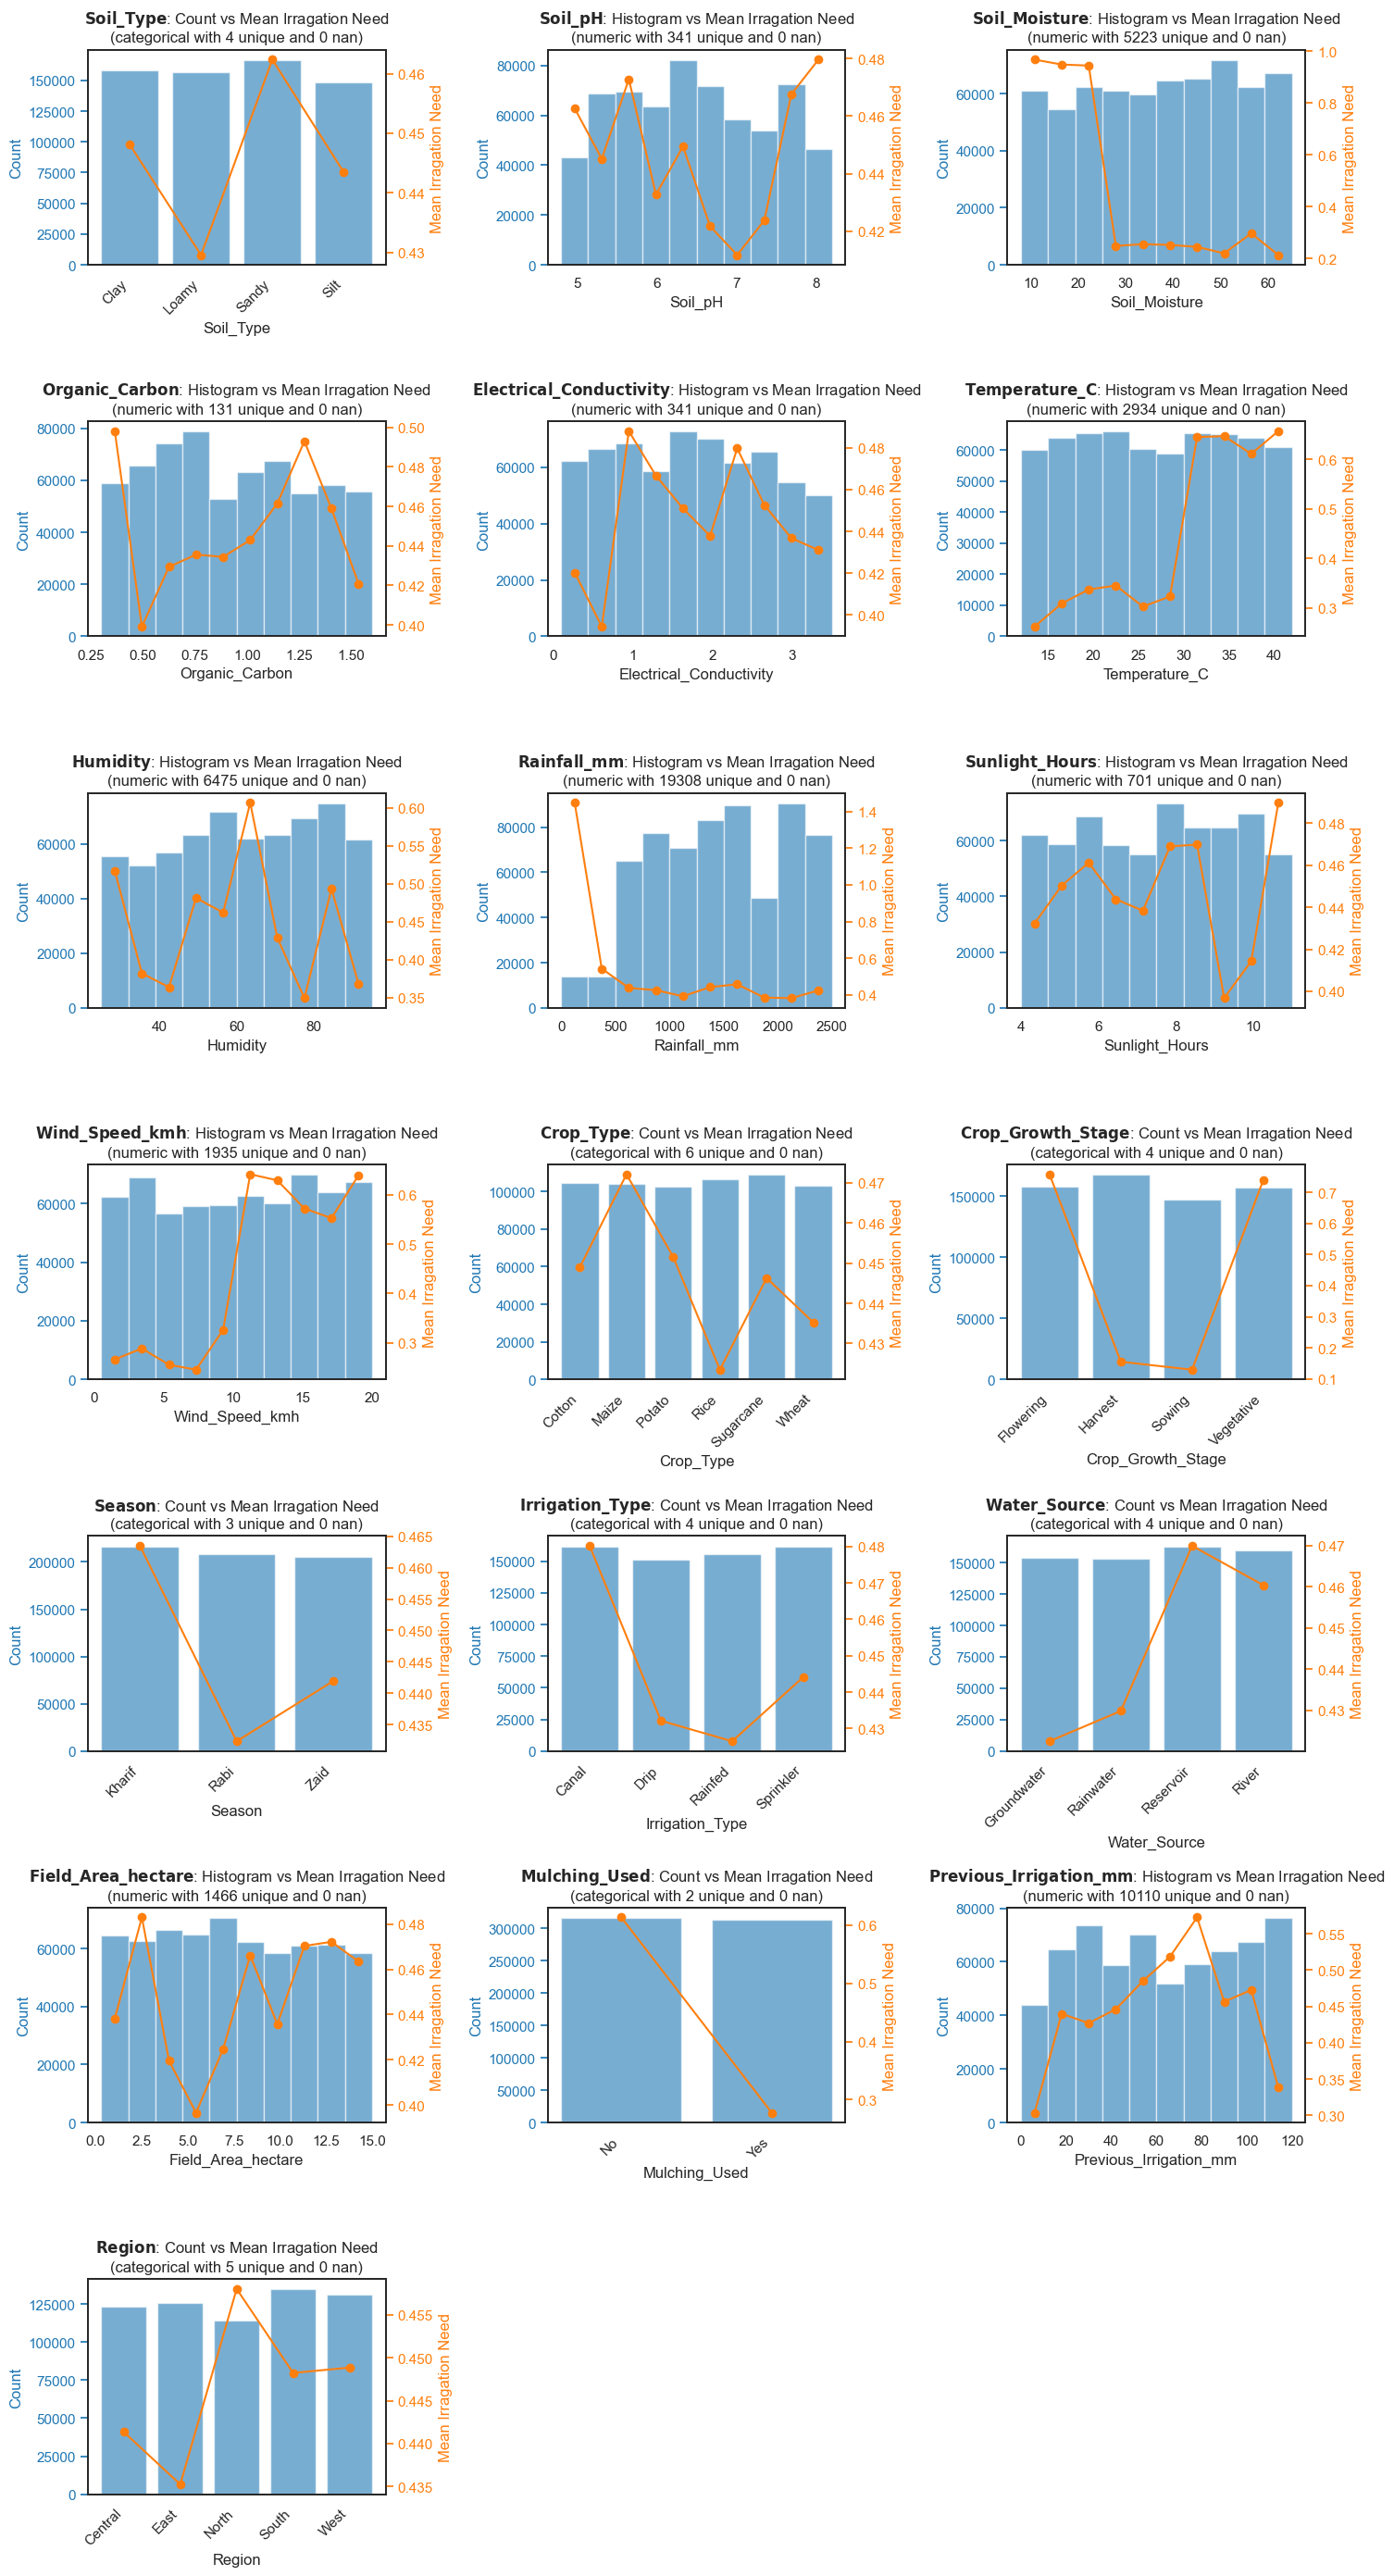

In [21]:
# Features (excluding id and original target)
FEATURES = [
'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 
'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 
'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 
'Mulching_Used', 'Previous_Irrigation_mm', 'Region']


train["target"] = train["Irrigation_Need"].map({"Low":0,"Medium":1,"High":2})

# Call the function
plot_features_dual_axis(
    train,
    cols=FEATURES,
    target_col="target",
    n_bins=10,
    n_wide=3,
    int_as_cat_unique_max=10,  # Treats columns with ≤10 unique values as categorical
    target_label="Mean Irragation Need",
)

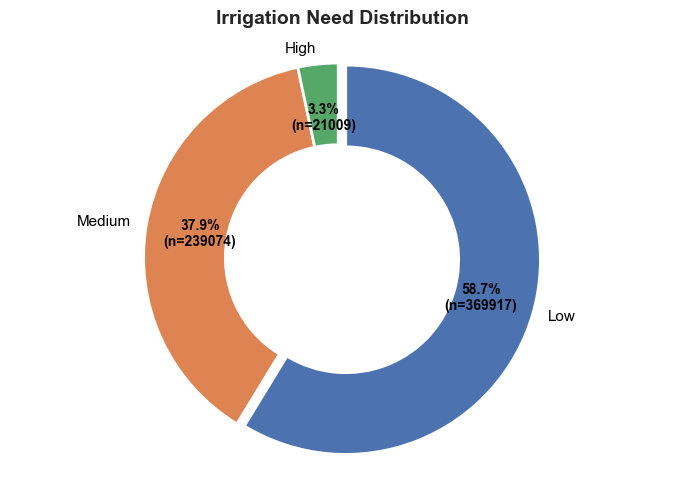

In [ ]:

counts = train["Irrigation_Need"].value_counts().sort_values(ascending=False)

def autopct_format(values):
    total = sum(values)
    def inner(pct):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(n={count})"
    return inner

fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")

explode = [0.04 if i == 0 else 0 for i in range(len(counts))]

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    autopct=autopct_format(counts.values),
    startangle=90,
    counterclock=False,
    explode=explode,
    pctdistance=0.72,
    labeldistance=1.08,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    textprops=dict(color="black", fontsize=11)
)

plt.setp(autotexts, fontsize=10, fontweight="semibold")
plt.setp(texts, fontsize=11)

ax.set_title("Irrigation Need Distribution", fontsize=14, fontweight="semibold", pad=14)
ax.axis("equal")

plt.tight_layout()
plt.show()

## Conclusions:
- The target is imbalanced: Low dominates, Medium is substantial, and High is rare, so model evaluation should focus on class balance, not just accuracy.
- Soil_Moisture, Temperature_C, Humidity, and Previous_Irrigation_mm appear to carry the strongest predictive signal for irrigation need.
- Most categorical variables show weaker standalone separation, so their value may come more from interactions with weather, soil, and field conditions. Feature interactions.
- Because the dataset is synthetic, patterns may be cleaner than real-world data, so strong scores may reflect generator rules as much as real agronomic behavior.